# This is a Jupyter Notebook for Image Classification using Fashion MNIST Dataset

Dataset Description:
Provided by MNIST database,this is one of the foundational datasets for learning Image Classification. This dataset contains images of 10 different types of clothing. The images are 28 X 28 grayscale.It has a nice variety of clothing including shirts,trousers,dresses,and lots of types of shoes. It's monochrome, so each picture consists of a certain number of pixels with values between 0 and 255. This makes the dataset simpler to manage.


In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
data = tf.keras.datasets.fashion_mnist

In [3]:
(training_images,training_labels),(test_images,test_labels) = data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
print(len(training_images))
print(len(test_images))
print('total : ' + str(len(training_images) + len(test_images)))

60000
10000
total : 70000


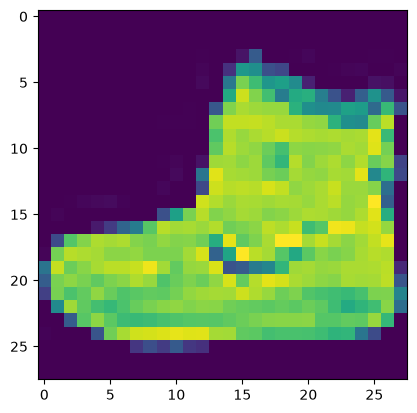

In [18]:
plt.imshow(training_images[0])
plt.show()

Like any Image, it's a rectangular grid of pixels. In this case the grid size is 28 X 28, and each pixel is simply a value between 0 and 255.

In [4]:
training_images = training_images / 255.0
test_images = test_images/255.0

In [5]:
#Designing the Neural Network

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)),
    tf.keras.layers.Dense(128,activation = tf.nn.relu),
    tf.keras.layers.Dense(10,activation = tf.nn.softmax)
])

C:\Users\sindh\PycharmProjects\ImageClassification\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequential Model is used to specify the layers.
The first, Flatten, isn't a layer of neurons, but an input layer specification. Our inputs are 28 x 28 images,but we want them to be treated as a numerical values.
The next one Dense, is a layer of neurons, and we are specifying that we want 128 of them. This the middle layer also called as Hidden layer. Why 128? This is entirely arbitrary there is no fixed rule for the number of neurons to use. The activation function is code that will execute on each neuron in the layer. TensorFlow supports a number of them, but a very common one in middle layers is relu, which stands for rectified linear unit. It’s a simple function that just returns a value if it’s greater than 0. In this case, we don’t want negative values being passed to the next layer to potentially impact the summing function, so instead of writing a lot of if-then code, we can simply activate the layer with relu. Finally, there’s another Dense layer, which is the output layer. This has 10 neurons, because we have 10 classes. Each of these neurons will end up with a probability that the input pixels match that class, so our job is to determine which one has the highest value. We could loop through them to pick that value, but the softmax activation function does that for us.

In [9]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

The loss function in this case is called sparse categorical cross entropy, and it’s one of
the arsenal of loss functions that are built into TensorFlow.
Our item of clothing will belong to 1 of 10 categories of clothing,
and thus using a categorical loss function is the way to go. Sparse categorical cross
entropy is a good choice.The same applies to choosing an optimizer. The adam optimizer is an evolution of the
stochastic gradient descent (sgd) optimizer that has been shown
to be faster and more efficient. As we’re handling 60,000 training images, any perfor‐
mance improvement we can get will be helpful, so that one is chosen here.

In [19]:
model.fit(training_images,training_labels,epochs = 50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8964 - loss: 0.2801
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8997 - loss: 0.2674
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9052 - loss: 0.2570
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9072 - loss: 0.2466
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9095 - loss: 0.2388
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9133 - loss: 0.2300
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9175 - loss: 0.2227
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9201 - loss: 0.2158
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9211 - loss: 0.2100
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9254 - loss: 0.2026
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9256 - loss: 0.1969
Epoch 12/50
1875/1875 ━━━━━━━━

In [21]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8841 - loss: 0.5542


[0.5542454123497009, 0.8841000199317932]

In [20]:
model.predict(test_images);

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
